Imagen generada con éxito


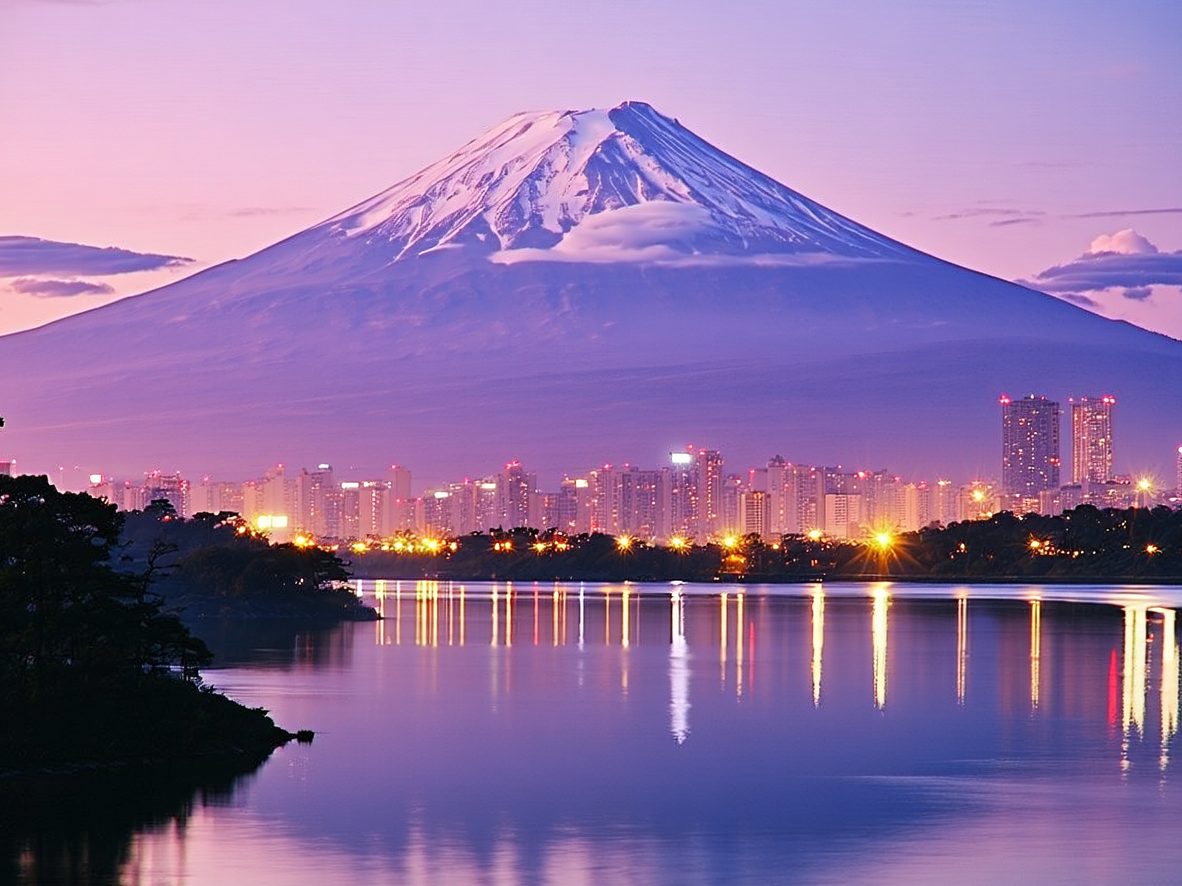

In [ ]:
import requests
import base64
from IPython.display import Image, display
import io

# URL base de la API (reemplázala con la URL real)
BASE_URL = "https://xxxx.eastus2.models.ai.azure.com"

# Endpoint para la generación de imágenes
IMAGE_GEN_ENDPOINT = f"{BASE_URL}/images/generations"

# Ruta de la imagen que quieres incluir en la petición
IMAGE_PATH = "./demo1.jpeg"  # Reemplázalo con la ruta real de tu imagen

# Convierte la imagen a Base64
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# Codifica la imagen en Base64
image_base64 = encode_image_to_base64(IMAGE_PATH)

# Datos de la solicitud
payload = {
    "prompt": "convert image with manga style",
    "size": "1024x1024",
    "output_format": "png",
    "n": 1,  # Número de imágenes a generar
    "image_prompt": {
        "image": image_base64,  # Imagen codificada en Base64
        "strength": 0.8  # Controla cuánto influye la imagen en la generación
    }
}

# Encabezados de la solicitud
headers = {
    'accept':'application/json',
    "Content-Type": "application/json",
    "Authorization": "Bearer APIKEY"  # Reemplázalo con tu clave de API si es necesario
}

# Realiza la solicitud POST a la API
response = requests.post(IMAGE_GEN_ENDPOINT, json=payload, headers=headers)

# Verifica la respuesta
if response.status_code == 200:
    print("Imagen generada con éxito")
    image_data = response.json()["image"]  # Ajusta esto según la estructura de tu respuesta
    image_bytes = base64.b64decode(image_data)
    display(Image(data=image_bytes))
else:
    print("Error en la solicitud:", response.status_code, response.text)
